# Do mid-campaign space-filling batches help? — three problems of increasing nastiness

The first version of this benchmark (sliced Hartmann-6 only) found that diverting budget to
space-filling batches *hurts* pure optimization. A fair objection: **maybe Hartmann-6 is too
easy** — smooth, broad basins are exactly where EI recovers from a thin initial design on its
own. This version re-runs the same four arms on **three problems chosen to span the hardness
axes where exploration batches could plausibly win**:

| Problem | Inputs | Character | Level structure (slice minima) |
|---|---|---|---|
| **Sliced Hartmann-6** | 5 cont + 2-level cat | smooth, broad basins ("easy") | level 1 hides the global (−3.32 vs −1.59) |
| **Sliced Shekel-4 (m=10)** | 3 cont + 2-level cat | **deceptive** — ten competing basins, global one narrow | level 1 hides the global (−10.54 vs −5.18) |
| **Sliced Michalewicz-5** | 5 cont + 2-level cat | **rugged** — needle valleys in a flat landscape; level switches steepness m ∈ {3, 10} | levels nearly tied (−4.70 vs −4.69) |

All are standard VLSE test functions adapted to the campaign's mixed continuous + categorical
structure. **Six arms**, identical GP (`utils.mobo.fit_gp`), fixed total budget of 60
evaluations:

* **Sobol + BO / LHS+SA + BO** — 12-point initial design, then 48 one-at-a-time LogEI evals.
* **… + batches** — same init, alternating 8 LogEI evals with an 8-point space-filling batch
  (Sobol continuation / `conditional_sa_lhs` freezing all points so far).
* **… + qNEI batches** — the *same* 12-point initial design, then **qLogNEI-proposed batches
  of 8** (sequential-greedy with pending points, one model fit per batch) — the closest analogue
  of the real campaign, where runs are fabricated in batches proposed by the acquisition.

Within each family, the initial design depends only on (sampler, seed), so for a given seed all
three arms start from the **identical 12 points** — every difference is purely post-init policy.
An 8-point small-init qNEI variant appears in §4, where the init-size effect is isolated.

Shared code: [`utils/doe_bo_test.py`](../../utils/doe_bo_test.py).

In [ ]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.doe_bo_test import PROBLEMS, run_campaign_p, regret_matrix

OUT_DIR = 'output/sampler_bo_1d_test'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

ARMS = {  # strategy -> (label, color, line style kwargs)
    'sobol_bo':        ('Sobol + BO',               '#1f77b4', dict(ls='-')),
    'lhs_sa_bo':       ('LHS+SA + BO',              '#d62728', dict(ls='-')),
    'sobol_bo_batch':  ('Sobol + BO + batches',     '#1f77b4', dict(ls='--')),
    'lhs_sa_bo_batch': ('LHS+SA + BO + batches',    '#d62728', dict(ls='--')),
    'sobol_qnei12':    ('Sobol + qNEI batches',    '#1f77b4',
                        dict(ls=(0, (1, 1)), marker='^', markevery=6, markersize=7,
                             markerfacecolor='white', markeredgewidth=1.5)),
    'lhs_sa_qnei12':   ('LHS+SA + qNEI batches',   '#d62728',
                        dict(ls=(0, (1, 1)), marker='^', markevery=6, markersize=7,
                             markerfacecolor='white', markeredgewidth=1.5)),
}
PROBLEM_LABELS = {'hartmann6':    'Sliced Hartmann-6 (smooth)',
                  'shekel4':      'Sliced Shekel-4 (deceptive)',
                  'michalewicz5': 'Sliced Michalewicz-5 (rugged)'}
N_SEEDS, N_INIT, TOTAL, BO_BLOCK, BATCH, SIGMA = 10, 12, 60, 8, 8, 0.2

for k in PROBLEM_LABELS:
    p = PROBLEMS[k]
    print(f'{k:13s} d_cont={p["d_cont"]}  slice minima: level0 {p["slice_min"][0.0]:8.3f}, '
          f'level1 {p["slice_min"][1.0]:8.3f}  (global {p["true_min"]:.3f})')

hartmann6     d_cont=5  slice minima: level0   -1.588, level1   -3.321  (global -3.321)
shekel4       d_cont=3  slice minima: level0   -5.176, level1  -10.536  (global -10.536)
michalewicz5  d_cont=5  slice minima: level0   -4.701, level1   -4.688  (global -4.701)


## 1. The three problems at a glance

Histograms of each level's value distribution (20 000 random points per level). Note how the
global optimum (dashed line) sits progressively further into the tail: Hartmann's basin is
broad, Shekel's is a needle far below the bulk (deceptive), and Michalewicz's two levels are
nearly indistinguishable by value.

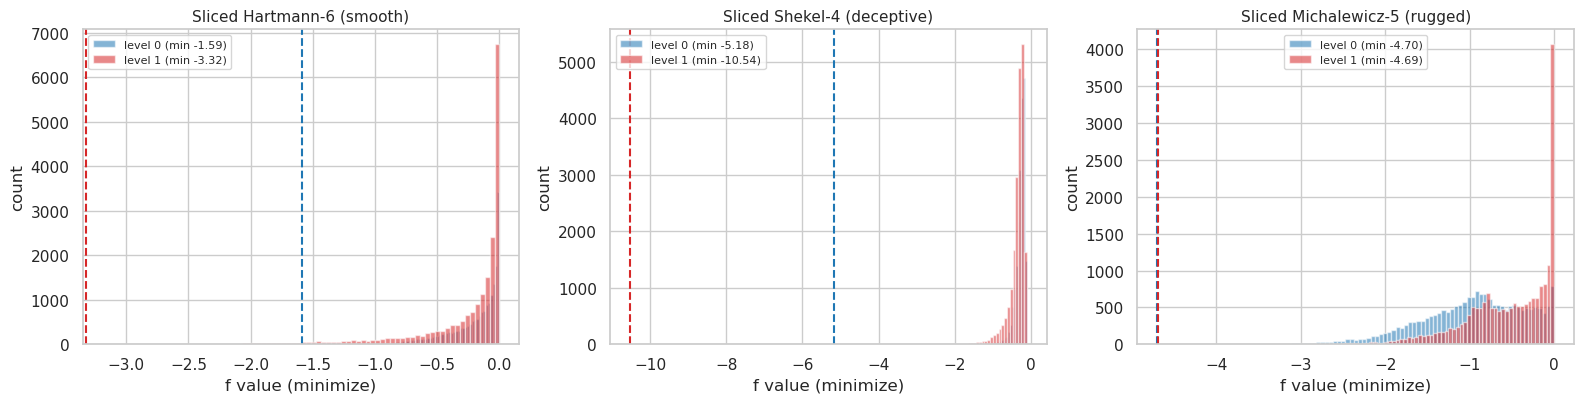

In [2]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, key in zip(axes, PROBLEM_LABELS):
    p = PROBLEMS[key]
    Xr = rng.random((20000, p['d_cont']))
    for lv, color in [(0.0, '#1f77b4'), (1.0, '#d62728')]:
        vals = p['f'](np.column_stack([Xr, np.full(len(Xr), lv)]))
        ax.hist(vals, bins=80, alpha=0.55, color=color,
                label=f'level {int(lv)} (min {p["slice_min"][lv]:.2f})')
        ax.axvline(p['slice_min'][lv], color=color, ls='--', lw=1.5)
    ax.set_title(PROBLEM_LABELS[key], fontsize=11)
    ax.set_xlabel('f value (minimize)'); ax.set_ylabel('count'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hd_problem_overview.png'), dpi=180, bbox_inches='tight')
plt.show()

## 2. Run the benchmark (3 problems × 4 arms × 10 seeds)

The arms are embarrassingly parallel, so on the cluster they are precomputed by 12 parallel
workers (`python -m utils.run_doe_bo_arm <problem> <strategy>`, see that module's docstring for
the xargs launcher) into `campaign_cache/`. `run_campaign_p` is deterministic per
(problem, strategy, seed), so the cell below loads the cache when present and computes inline
otherwise — either path gives identical results.

In [3]:
import pickle
CACHE = os.path.join(OUT_DIR, 'campaign_cache')
results = {}
for p in PROBLEM_LABELS:
    results[p] = {}
    for s in ARMS:
        fp = os.path.join(CACHE, f'{p}__{s}.pkl')
        if os.path.exists(fp):
            with open(fp, 'rb') as fh:
                results[p][s] = pickle.load(fh)[:N_SEEDS]
            src = 'cache'
        else:
            results[p][s] = [run_campaign_p(p, s, seed, n_init=N_INIT, total=TOTAL,
                                            bo_block=BO_BLOCK, batch_size=BATCH, sigma=SIGMA)
                             for seed in range(N_SEEDS)]
            src = 'computed inline'
        print(f'{p} / {s}: {len(results[p][s])} seeds ({src})')
R = {p: {k: regret_matrix(v) for k, v in d.items()} for p, d in results.items()}
def arm_evals(r):   # per-arm x-axis: qNEI arms start from a smaller init, so histories differ
    return np.arange(TOTAL - r.shape[1] + 1, TOTAL + 1)

hartmann6 / sobol_bo: 10 seeds (cache)
hartmann6 / lhs_sa_bo: 10 seeds (cache)
hartmann6 / sobol_bo_batch: 10 seeds (cache)
hartmann6 / lhs_sa_bo_batch: 10 seeds (cache)
hartmann6 / sobol_qnei12: 10 seeds (cache)
hartmann6 / lhs_sa_qnei12: 10 seeds (cache)
shekel4 / sobol_bo: 10 seeds (cache)
shekel4 / lhs_sa_bo: 10 seeds (cache)
shekel4 / sobol_bo_batch: 10 seeds (cache)
shekel4 / lhs_sa_bo_batch: 10 seeds (cache)
shekel4 / sobol_qnei12: 10 seeds (cache)
shekel4 / lhs_sa_qnei12: 10 seeds (cache)
michalewicz5 / sobol_bo: 10 seeds (cache)
michalewicz5 / lhs_sa_bo: 10 seeds (cache)
michalewicz5 / sobol_bo_batch: 10 seeds (cache)
michalewicz5 / lhs_sa_bo_batch: 10 seeds (cache)
michalewicz5 / sobol_qnei12: 10 seeds (cache)
michalewicz5 / lhs_sa_qnei12: 10 seeds (cache)


## 3. Results

Tolerance for "solved" is scaled per problem: regret ≤ 10 % of |global min|.

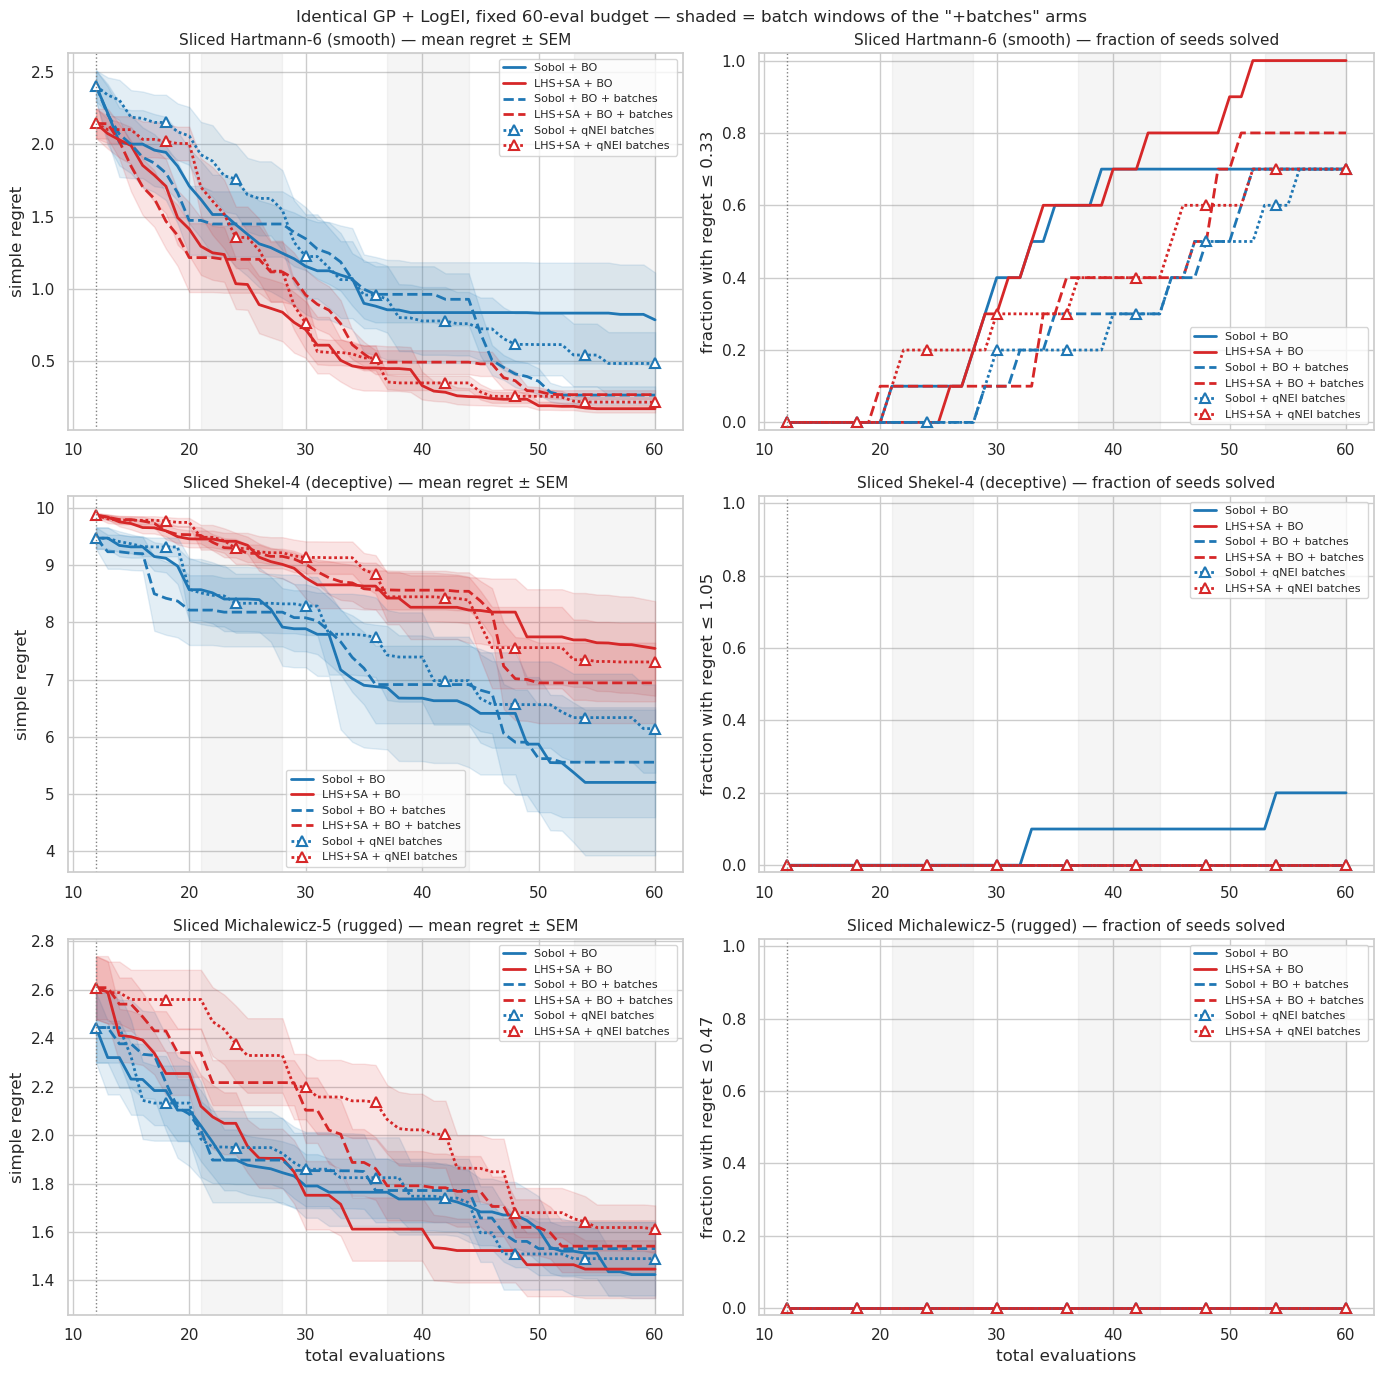

In [4]:
batch_spans = []
pos = N_INIT
while pos < TOTAL:
    pos += BO_BLOCK
    if pos < TOTAL:
        batch_spans.append((pos + 1, min(pos + BATCH, TOTAL))); pos += BATCH

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row, key in zip(axes, PROBLEM_LABELS):
    tol = 0.1 * abs(PROBLEMS[key]['true_min'])
    for arm, (label, color, style) in ARMS.items():
        r = R[key][arm]; ev = arm_evals(r)
        mu, sem = r.mean(0), r.std(0) / np.sqrt(r.shape[0])
        row[0].plot(ev, mu, color=color, label=label, lw=2, **style)
        row[0].fill_between(ev, mu - sem, mu + sem, color=color, alpha=0.12)
        row[1].plot(ev, (r <= tol).mean(0), color=color, label=label, lw=2, **style)
    for a, b in batch_spans:
        for ax in row:
            ax.axvspan(a, b, color='gray', alpha=0.08)
    row[0].set_ylabel('simple regret')
    row[0].set_title(f'{PROBLEM_LABELS[key]} — mean regret ± SEM', fontsize=11)
    row[1].set_ylabel(f'fraction with regret ≤ {tol:.2f}')
    row[1].set_title(f'{PROBLEM_LABELS[key]} — fraction of seeds solved', fontsize=11)
    row[1].set_ylim(-0.02, 1.02)
    for ax in row:
        ax.axvline(N_INIT, ls=':', color='gray', lw=1); ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('total evaluations')
fig.suptitle('Identical GP + LogEI, fixed 60-eval budget — shaded = batch windows of the '
             '"+batches" arms', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hd_regret_comparison.png'), dpi=180, bbox_inches='tight')
plt.show()

In [5]:
rows = []
for key in PROBLEM_LABELS:
    tol = 0.1 * abs(PROBLEMS[key]['true_min'])
    for arm, (label, *_ ) in ARMS.items():
        r = R[key][arm]
        rows.append({'problem': key, 'arm': label,
                     'regret after own init':  round(float(r[:, 0].mean()), 3),
                     'final regret (mean)':   round(float(r[:, -1].mean()), 3),
                     'final regret (median)': round(float(np.median(r[:, -1])), 3),
                     f'seeds solved (10% tol)': f'{int((r[:, -1] <= tol).sum())}/{r.shape[0]}'})
summary = pd.DataFrame(rows)
summary.to_excel(os.path.join(OUT_DIR, 'hd_benchmark_summary.xlsx'), index=False)

print('Per-seed final-regret wins (within each sampler family):')
for key in PROBLEM_LABELS:
    for fam, a, b, la, lb in [('Sobol', 'sobol_bo', 'sobol_bo_batch', 'pure', '+batches'),
                              ('LHS+SA', 'lhs_sa_bo', 'lhs_sa_bo_batch', 'pure', '+batches'),
                              ('Sobol', 'sobol_bo', 'sobol_qnei12', 'pure', 'qNEI'),
                              ('LHS+SA', 'lhs_sa_bo', 'lhs_sa_qnei12', 'pure', 'qNEI')]:
        fa, fb = R[key][a][:, -1], R[key][b][:, -1]
        w_a, w_b = int((fa < fb - 1e-9).sum()), int((fb < fa - 1e-9).sum())
        print(f'  {key:13s} {fam:7s}: {la} {w_a} | {lb} {w_b} | ties {len(fa) - w_a - w_b}')
summary

Per-seed final-regret wins (within each sampler family):
  hartmann6     Sobol  : pure 5 | +batches 5 | ties 0
  hartmann6     LHS+SA : pure 8 | +batches 2 | ties 0
  hartmann6     Sobol  : pure 8 | qNEI 2 | ties 0
  hartmann6     LHS+SA : pure 5 | qNEI 5 | ties 0
  shekel4       Sobol  : pure 5 | +batches 4 | ties 1
  shekel4       LHS+SA : pure 5 | +batches 5 | ties 0
  shekel4       Sobol  : pure 6 | qNEI 4 | ties 0
  shekel4       LHS+SA : pure 6 | qNEI 4 | ties 0
  michalewicz5  Sobol  : pure 5 | +batches 5 | ties 0
  michalewicz5  LHS+SA : pure 5 | +batches 5 | ties 0
  michalewicz5  Sobol  : pure 6 | qNEI 4 | ties 0
  michalewicz5  LHS+SA : pure 7 | qNEI 3 | ties 0


,problem,arm,regret after own init,final regret (mean),final regret (median),seeds solved (10% tol)
0,hartmann6,Sobol + BO,2.405,0.786,0.161,7/10
1,hartmann6,LHS+SA + BO,2.145,0.171,0.169,10/10
2,hartmann6,Sobol + BO + batches,2.405,0.265,0.181,7/10
3,hartmann6,LHS+SA + BO + batches,2.145,0.268,0.248,8/10
4,hartmann6,Sobol + qNEI batches,2.405,0.484,0.269,7/10
5,hartmann6,LHS+SA + qNEI batches,2.145,0.216,0.181,7/10
6,shekel4,Sobol + BO,9.473,5.204,5.403,2/10
7,shekel4,LHS+SA + BO,9.872,7.545,8.970,0/10
8,shekel4,Sobol + BO + batches,9.473,5.557,4.373,0/10
9,shekel4,LHS+SA + BO + batches,9.872,6.943,7.055,0/10


## 4. Isolating the batch policy

The arms above mix several factors (init size, sequential vs batch, batch content). The arms in
this section hold everything else fixed — **same 12-point init, everything afterwards delivered
in batches of 8, no sequential steps** — and vary *only what the batches contain*:

* **qNEI batches (12 init)** — every batch BO-proposed (`_qnei12`);
* **mixed 6 + 2** — each batch = 6 qNEI points + 2 space-filling points conditioned on
  everything including the pending qNEI picks (`_mixed`) — the "fixed exploration ration" policy;
* **SF only** — every batch space-filling, no BO at all (`_sf_only`) — i.e. an incrementally
  extended DoE, the no-model baseline.

Sequential BO (the unimplementable ceiling) and the small-init qNEI arm are shown for reference.
Color now encodes the **policy** (the entity under comparison); columns are the two initializer
families.

In [6]:
POLICIES = {  # policy -> (label, color); color follows the policy across both families
    'bo':      ('sequential BO (ceiling)',    '#444444'),
    'qnei12':  ('qNEI batches (12 init)',     '#2ca02c'),
    'mixed':   ('mixed 6 qNEI + 2 SF',        '#17becf'),
    'qnei':    ('qNEI batches (8 init)',      '#9467bd'),
    'sf_only': ('SF batches only (no BO)',    '#8c564b'),
}
FAMS = {'sobol': 'Sobol init', 'lhs_sa': 'LHS+SA init'}

for p in PROBLEM_LABELS:                      # load the extra arms into R (cache-aware)
    for fam in FAMS:
        for pol in POLICIES:
            arm = f'{fam}_{pol}'
            if arm in R[p]:
                continue
            fp = os.path.join(CACHE, f'{p}__{arm}.pkl')
            if os.path.exists(fp):
                with open(fp, 'rb') as fh:
                    R[p][arm] = regret_matrix(pickle.load(fh)[:N_SEEDS])
            else:
                R[p][arm] = regret_matrix([run_campaign_p(p, arm, seed, n_init=N_INIT,
                                                          total=TOTAL, bo_block=BO_BLOCK,
                                                          batch_size=BATCH, sigma=SIGMA)
                                           for seed in range(N_SEEDS)])
print('extra arms loaded')

extra arms loaded


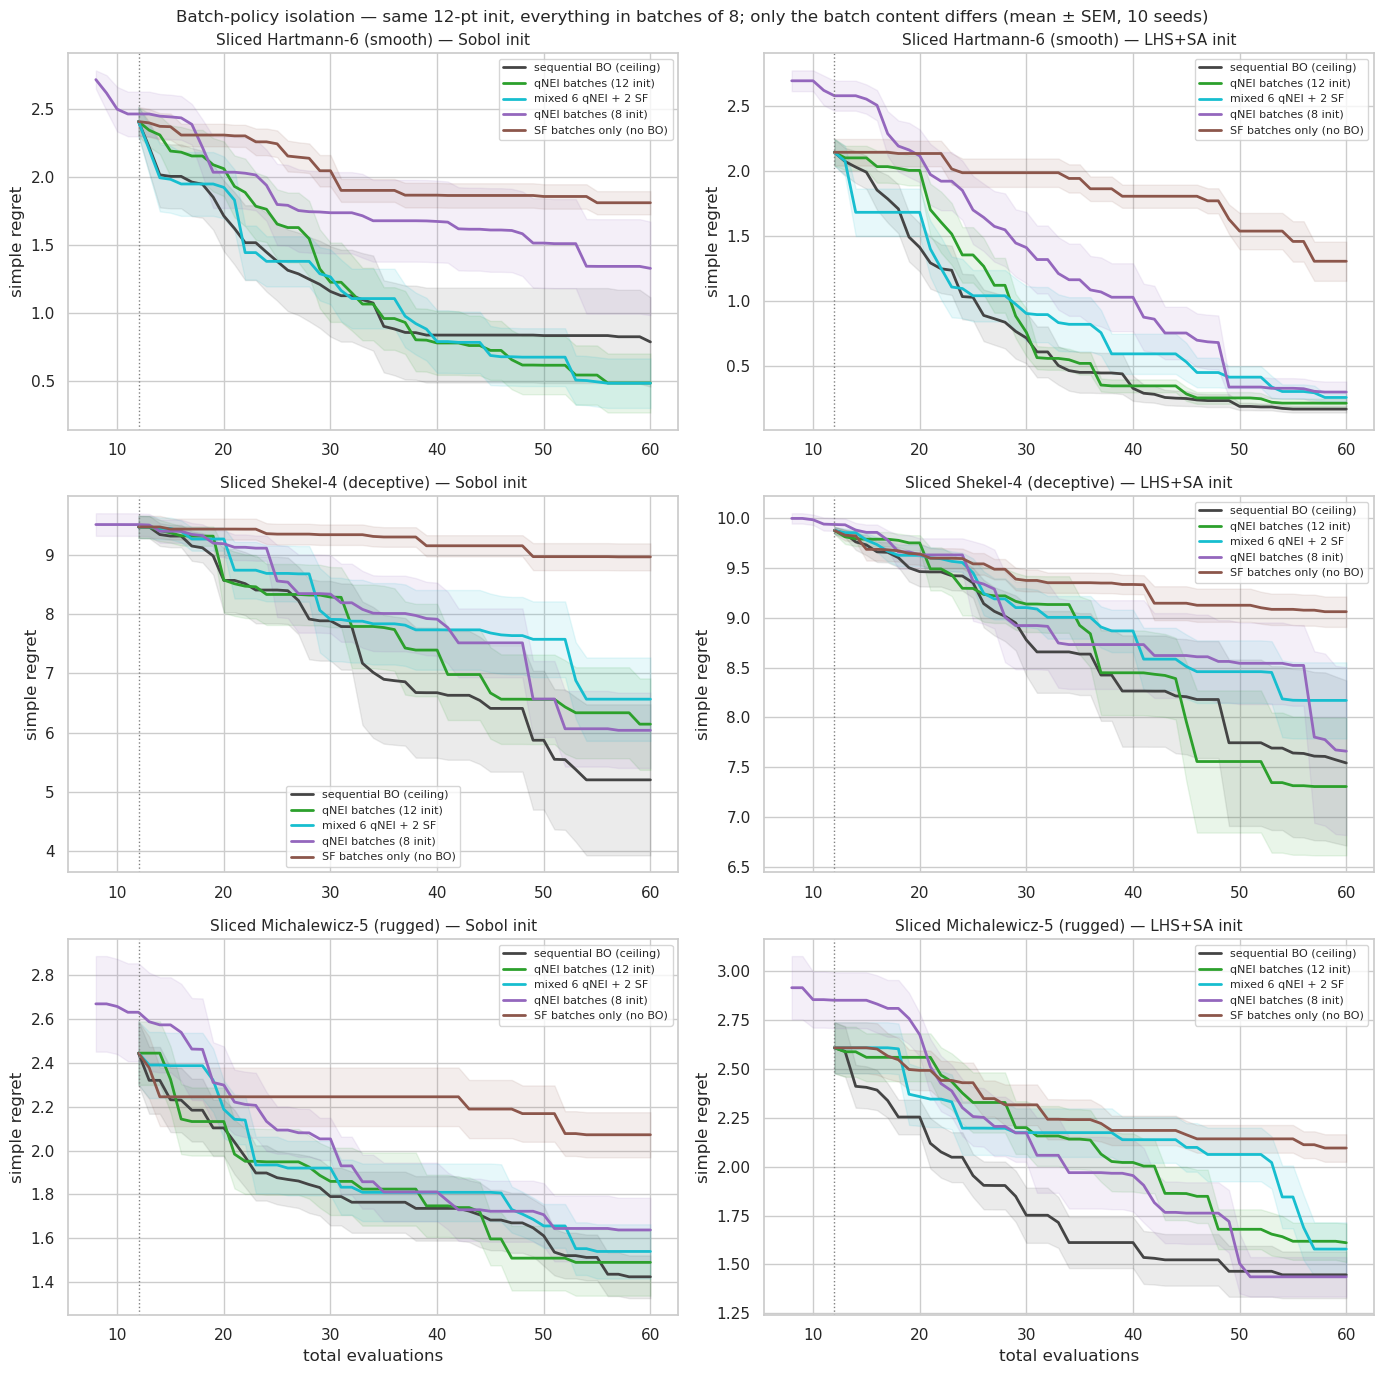

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row, key in zip(axes, PROBLEM_LABELS):
    for col, (fam, fam_label) in zip(row, FAMS.items()):
        for pol, (label, color) in POLICIES.items():
            r = R[key][f'{fam}_{pol}']; ev = arm_evals(r)
            mu, sem = r.mean(0), r.std(0) / np.sqrt(r.shape[0])
            col.plot(ev, mu, '-', color=color, label=label, lw=2)
            col.fill_between(ev, mu - sem, mu + sem, color=color, alpha=0.10)
        col.axvline(N_INIT, ls=':', color='gray', lw=1)
        col.set_title(f'{PROBLEM_LABELS[key]} — {fam_label}', fontsize=11)
        col.set_ylabel('simple regret'); col.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('total evaluations')
fig.suptitle('Batch-policy isolation — same 12-pt init, everything in batches of 8; '
             'only the batch content differs (mean ± SEM, 10 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hd_batch_policy_isolation.png'), dpi=180, bbox_inches='tight')
plt.show()

In [8]:
rows = []
for key in PROBLEM_LABELS:
    tol = 0.1 * abs(PROBLEMS[key]['true_min'])
    for fam in FAMS:
        for pol, (label, _) in POLICIES.items():
            r = R[key][f'{fam}_{pol}']
            rows.append({'problem': key, 'family': fam, 'policy': label,
                         'final regret (mean)':   round(float(r[:, -1].mean()), 3),
                         'final regret (median)': round(float(np.median(r[:, -1])), 3),
                         f'seeds solved (10% tol)': f'{int((r[:, -1] <= tol).sum())}/{r.shape[0]}'})
policy_tbl = pd.DataFrame(rows)
policy_tbl.to_excel(os.path.join(OUT_DIR, 'hd_batch_policy_summary.xlsx'), index=False)

print('Targeted per-seed win counts (final regret):')
for key in PROBLEM_LABELS:
    for fam in FAMS:
        for a, b in [('qnei12', 'sf_only'), ('qnei12', 'mixed'), ('mixed', 'sf_only'),
                     ('qnei12', 'qnei'), ('bo', 'qnei12')]:
            fa, fb = R[key][f'{fam}_{a}'][:, -1], R[key][f'{fam}_{b}'][:, -1]
            wa, wb = int((fa < fb - 1e-9).sum()), int((fb < fa - 1e-9).sum())
            print(f'  {key:13s} {fam:7s} {a:7s} vs {b:8s}: {wa}:{wb} (ties {N_SEEDS - wa - wb})')
policy_tbl

Targeted per-seed win counts (final regret):
  hartmann6     sobol   qnei12  vs sf_only : 9:1 (ties 0)
  hartmann6     sobol   qnei12  vs mixed   : 5:3 (ties 2)
  hartmann6     sobol   mixed   vs sf_only : 9:1 (ties 0)
  hartmann6     sobol   qnei12  vs qnei    : 6:1 (ties 3)
  hartmann6     sobol   bo      vs qnei12  : 8:2 (ties 0)
  hartmann6     lhs_sa  qnei12  vs sf_only : 10:0 (ties 0)
  hartmann6     lhs_sa  qnei12  vs mixed   : 4:1 (ties 5)
  hartmann6     lhs_sa  mixed   vs sf_only : 10:0 (ties 0)
  hartmann6     lhs_sa  qnei12  vs qnei    : 3:2 (ties 5)
  hartmann6     lhs_sa  bo      vs qnei12  : 5:5 (ties 0)
  shekel4       sobol   qnei12  vs sf_only : 10:0 (ties 0)
  shekel4       sobol   qnei12  vs mixed   : 7:2 (ties 1)
  shekel4       sobol   mixed   vs sf_only : 10:0 (ties 0)
  shekel4       sobol   qnei12  vs qnei    : 3:3 (ties 4)
  shekel4       sobol   bo      vs qnei12  : 6:4 (ties 0)
  shekel4       lhs_sa  qnei12  vs sf_only : 6:4 (ties 0)
  shekel4       lhs_sa 

,problem,family,policy,final regret (mean),final regret (median),seeds solved (10% tol)
0,hartmann6,sobol,sequential BO (ceiling),0.786,0.161,7/10
1,hartmann6,sobol,qNEI batches (12 init),0.484,0.269,7/10
2,hartmann6,sobol,mixed 6 qNEI + 2 SF,0.482,0.276,6/10
3,hartmann6,sobol,qNEI batches (8 init),1.326,1.222,4/10
4,hartmann6,sobol,SF batches only (no BO),1.808,1.702,0/10
5,hartmann6,lhs_sa,sequential BO (ceiling),0.171,0.169,10/10
6,hartmann6,lhs_sa,qNEI batches (12 init),0.216,0.181,7/10
7,hartmann6,lhs_sa,mixed 6 qNEI + 2 SF,0.260,0.265,7/10
8,hartmann6,lhs_sa,qNEI batches (8 init),0.301,0.213,7/10
9,hartmann6,lhs_sa,SF batches only (no BO),1.307,1.460,0/10


## 5. Conclusion

Six main arms + the batch-policy isolation arms, three problems, 10 seeds each, fixed
60-evaluation budget:

**Pure BO vs space-filling batches:**

1. **Smooth (Hartmann-6):** pure BO from a good 12-point design wins (LHS+SA + BO: 0.17,
   10/10 solved), but batches act as **insurance against exploitation lock-in** — Sobol + BO's
   mean (0.79) is dragged up by three stuck seeds that its "+batches" variant rescues (0.27 at
   the same median).
2. **Deceptive (Shekel-4):** batches help the median/mean slightly, but **no arm solves the
   problem** — the budget, not its allocation, binds.
3. **Rugged (Michalewicz-5):** all arms tie; the GP itself is the bottleneck.

**The qNEI arms — identical 12-point init + qLogNEI batches of 8** (the closest analogue of
the real fabricate-in-batches campaign):

4. **Batch-mode BO costs little at the same starting points.** From the identical 12-point
   init, LHS+SA + qNEI batches reach 0.22 mean on Hartmann vs 0.17 for one-at-a-time sequential
   BO — with ~6 model fits instead of 48. In the Sobol family the batch arm's *mean* is even
   better than sequential (0.48 vs 0.79; per-seed still 8:2 for sequential): qNEI's
   within-batch diversity avoids part of the sequential arm's stuck-seed tail. On Shekel and
   Michalewicz the qNEI arms are statistically indistinguishable from sequential.
5. **Shrinking the init hurts batch BO — and the initializer decides by how much (§4).**
   qNEI from 8 points vs the same policy from 12: Sobol degrades badly (1.33 vs 0.48 mean on
   Hartmann) while LHS+SA degrades gracefully (0.30 vs 0.22). With refits this rare, the
   initial design's coverage carries the model — the better space-filling of LHS+SA matters
   most exactly when the initial batch is small.

**Batch-policy isolation (§4)** — same 12-point init, everything in batches, only the batch
content varies:

6. **Model-guided batches beat blind coverage decisively.** qNEI(12) beats SF-only on every
   problem and family (win counts 6:4 up to 10:0; Hartmann LHS+SA: 0.22 vs 1.31). SF-only — an
   incrementally extended DoE with no BO — is the **worst arm everywhere**, which quantifies
   the value of the BO stage itself.
7. **The mixed 6 qNEI + 2 SF policy costs little and never wins.** Pure qNEI edges it modestly
   (e.g. 7:3, 7:2) or ties; on Hartmann-Sobol the two are indistinguishable (0.482 vs 0.484).
   The 2-point exploration ration is a *cheap insurance premium* whose payoff did not
   materialize within these 10 seeds — defensible as robustness, not as performance.
8. **Init size matters in batch mode:** qNEI(12) recovers most of the small-init penalty
   (Sobol family: 0.48 vs 1.33 mean on Hartmann).
9. **Batching costs little at matched init — and its within-batch diversity even softens
   lock-in:** sequential BO still wins per-seed (e.g. 8:2, 7:3), but on Hartmann-Sobol the
   batch arm's *mean* is better (0.48 vs 0.79) because qNEI's pending-point diversity avoided
   part of the sequential arm's stuck-seed tail.

**Overall recipe for the campaign:** a good **LHS+SA initial design** (its advantage grows as
the initial batch shrinks), then **qNEI/qLogNEHVI-proposed batches** as the default. A small
fixed space-filling ration inside each batch is an acceptable low-cost hedge (point 7), and a
full space-filling batch is worth inserting only when model diagnostics look untrustworthy —
never as the routine policy (point 6). On genuinely deceptive or rugged responses, negotiate
**more total budget** — no allocation strategy substitutes for evaluations.

**Caveats.** 10 seeds; single-objective; Sobol/LHS+SA rankings on individual problems move
within noise across replications (the small-init qNEI gap is the largest and most consistent
initializer effect observed).